<a href="https://colab.research.google.com/github/SAI-SON/car_price/blob/main/practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import random

In [ ]:
np.random.seed(42)
random.seed(42)


In [ ]:
student_idsn_rows=300
genders_choices=['Male','Female','M','F','m','f']
depts=['CS','IT','ECE','Mech','Civil',np.nan]

In [ ]:
student_ids = np.arange(1001, 1001 + n_rows)


In [ ]:
gender = np.random.choice(genders_choices, n_rows, p=[0.4, 0.4, 0.05, 0.05, 0.05, 0.05])

In [ ]:
age = np.random.choice([19, 20, 21, 22, 23, np.nan], n_rows, p=[0.2, 0.3, 0.3, 0.1, 0.05, 0.05])

In [ ]:
department = np.random.choice(depts, n_rows, p=[0.3, 0.25, 0.2, 0.1, 0.1, 0.05])

In [ ]:
gpa = np.round(np.random.uniform(2.0, 4.0, n_rows), 2)

In [ ]:
attendance = np.random.uniform(60, 100, n_rows)
# Introduce some NaNs
attendance[np.random.choice(n_rows, 15, replace=False)] = np.nan
# Introduce some low attendance (outliers)
attendance[np.random.choice(n_rows, 5, replace=False)] = 30.0
attendance = np.round(attendance, 1)

In [ ]:
study_hours = np.round(np.random.uniform(0, 30, n_rows), 1)

In [ ]:
job = np.random.choice(['Yes', 'No'], n_rows)

In [ ]:
extra_curr = np.random.choice(['Yes', 'No', np.nan], n_rows, p=[0.4, 0.5, 0.1])

In [ ]:
distance = np.round(np.random.uniform(1, 50, n_rows), 1)

In [ ]:
exam_score = 40 + (study_hours * 1.5) + (gpa * 10) + np.random.normal(0, 5, n_rows)
exam_score = np.clip(exam_score, 0, 100).astype(int)

In [ ]:
placement_status = []
for i in range(n_rows):
    if (exam_score[i] > 75) and (attendance[i] > 70 or np.isnan(attendance[i])):
            placement_status.append('Placed')
    else:
            placement_status.append('Not Placed')

In [ ]:
df = pd.DataFrame({
      'Student_ID': student_ids,
          'Gender': gender,
              'Age': age,
                  'Department': department,
                      'High_School_GPA': gpa,
                          'Attendance_Rate': attendance,
                              'Study_Hours_Per_Week': study_hours,
                                  'Part_Time_Job': job,
                                      'Extra_Curricular_Activities': extra_curr,
                                          'Distance_From_Home_km': distance,
                                              'Exam_Score': exam_score,
                                                  'Placement_Status': placement_status
                                                  })


In [ ]:
df = pd.concat([df, df.iloc[0:5]], ignore_index=True)

In [46]:
df.to_csv('student_data_300.csv', index=False)

In [49]:
df_processing = pd.read_csv('student_data_300.csv')
print(df_processing.head())

   Student_ID  Gender   Age Department  High_School_GPA  Attendance_Rate  \
0        1001    Male  20.0         IT             3.83              NaN   
1        1002  Female  19.0         IT             3.07             62.5   
2        1003  Female  19.0         CS             2.32             78.4   
3        1004  Female  21.0         IT             3.39             89.3   
4        1005  Female  20.0         IT             3.59             84.3   

   Study_Hours_Per_Week Part_Time_Job Extra_Curricular_Activities  \
0                  24.7            No                          No   
1                  27.0            No                          No   
2                  16.6            No                          No   
3                  24.4           Yes                          No   
4                  11.5            No                         Yes   

   Distance_From_Home_km  Exam_Score Placement_Status  
0                   26.2         100           Placed  
1               

In [51]:
print(df_processing.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Student_ID                   310 non-null    int64  
 1   Gender                       310 non-null    object 
 2   Age                          295 non-null    float64
 3   Department                   292 non-null    object 
 4   High_School_GPA              310 non-null    float64
 5   Attendance_Rate              293 non-null    float64
 6   Study_Hours_Per_Week         310 non-null    float64
 7   Part_Time_Job                310 non-null    object 
 8   Extra_Curricular_Activities  286 non-null    object 
 9   Distance_From_Home_km        310 non-null    float64
 10  Exam_Score                   310 non-null    int64  
 11  Placement_Status             310 non-null    object 
dtypes: float64(5), int64(2), object(5)
memory usage: 29.2+ KB
None


In [53]:
print(df_processing.isnull().sum())

Student_ID                      0
Gender                          0
Age                            15
Department                     18
High_School_GPA                 0
Attendance_Rate                17
Study_Hours_Per_Week            0
Part_Time_Job                   0
Extra_Curricular_Activities    24
Distance_From_Home_km           0
Exam_Score                      0
Placement_Status                0
dtype: int64


In [56]:
print(f"Duplicates before: {df_processing.duplicated().sum()}")
df_processing.drop_duplicates(inplace=True)
print(f"Duplicates after: {df_processing.duplicated().sum()}")

Duplicates before: 0
Duplicates after: 0


In [58]:
print("Unique Genders before:", df_processing['Gender'].unique())
df_processing['Gender'] = df_processing['Gender'].replace({'m': 'Male', 'M': 'Male', 'f': 'Female', 'F': 'Female'})
print("Unique Genders after:", df_processing['Gender'].unique())

Unique Genders before: ['Male' 'Female']
Unique Genders after: ['Male' 'Female']


In [60]:
df_processing['Age'] = df_processing['Age'].fillna(df_processing['Age'].mean().round(0))
df_processing['Attendance_Rate'] = df_processing['Attendance_Rate'].fillna(df_processing['Attendance_Rate'].median())
df_processing.dropna(subset=['Department'], inplace=True)

print("Missing values after cleaning:")
print(df_processing.isnull().sum())

Missing values after cleaning:
Student_ID                      0
Gender                          0
Age                             0
Department                      0
High_School_GPA                 0
Attendance_Rate                 0
Study_Hours_Per_Week            0
Part_Time_Job                   0
Extra_Curricular_Activities    24
Distance_From_Home_km           0
Exam_Score                      0
Placement_Status                0
dtype: int64


In [62]:
df_processing['Study_Efficiency'] = df_processing['Exam_Score'] / (df_processing['Study_Hours_Per_Week'] + 1)

print("New column 'Study_Efficiency' created successfully.")

New column 'Study_Efficiency' created successfully.


In [64]:
numeric_df_processing = df_processing.select_dtypes(include=[np.number])
correlation_matrix = numeric_df_processing.corr()

print(correlation_matrix['Exam_Score'])

Student_ID              -0.012027
Age                     -0.050504
High_School_GPA          0.392090
Attendance_Rate          0.016114
Study_Hours_Per_Week     0.801982
Distance_From_Home_km   -0.088900
Exam_Score               1.000000
Study_Efficiency        -0.585747
Name: Exam_Score, dtype: float64


In [66]:
print(df_processing.groupby('Department')['Exam_Score'].mean().sort_values(ascending=False))

Department
Civil    92.545455
IT       90.265060
Mech     89.300000
CS       88.566667
ECE      87.280702
Name: Exam_Score, dtype: float64


In [68]:
df_processing.to_csv('student_data_cleaned.csv', index=False)

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
df_viz = pd.read_csv('student_data_cleaned.csv')

In [75]:
sns.set_style("whitegrid")

print("Seaborn plotting style set to 'whitegrid'.")

Seaborn plotting style set to 'whitegrid'.


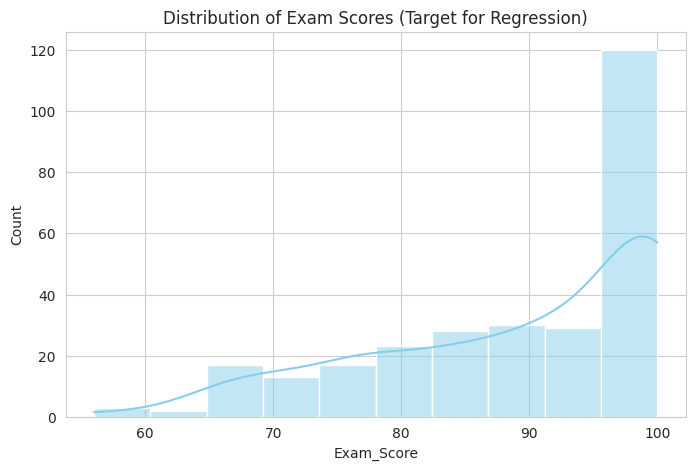

In [78]:
plt.figure(figsize=(8, 5))
sns.histplot(df_viz['Exam_Score'], kde=True, color='skyblue')
plt.title('Distribution of Exam Scores (Target for Regression)')
plt.show()

/tmp/ipython-input-738428686.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Placement_Status', data=df_viz, palette='viridis')


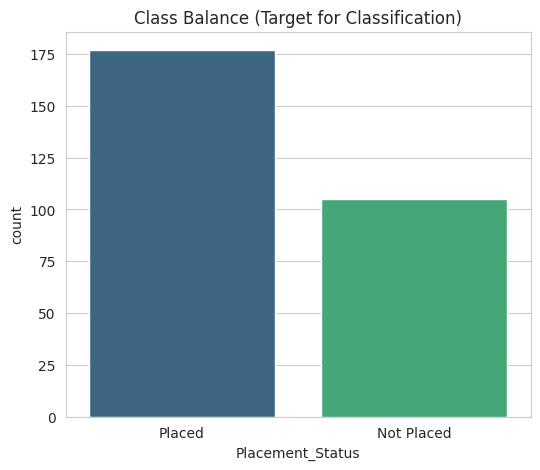

In [82]:
plt.figure(figsize=(6, 5))
sns.countplot(x='Placement_Status', data=df_viz, palette='viridis')
plt.title('Class Balance (Target for Classification)')
plt.show()

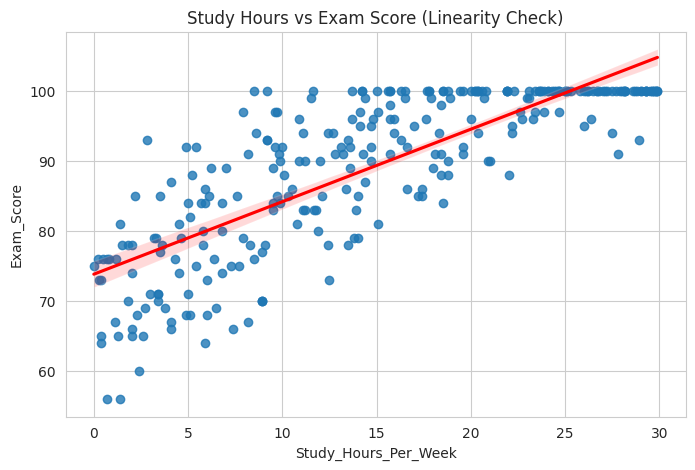

In [83]:
plt.figure(figsize=(8, 5))
sns.regplot(x='Study_Hours_Per_Week', y='Exam_Score', data=df_viz, line_kws={'color':'red'})
plt.title('Study Hours vs Exam Score (Linearity Check)')
plt.show()

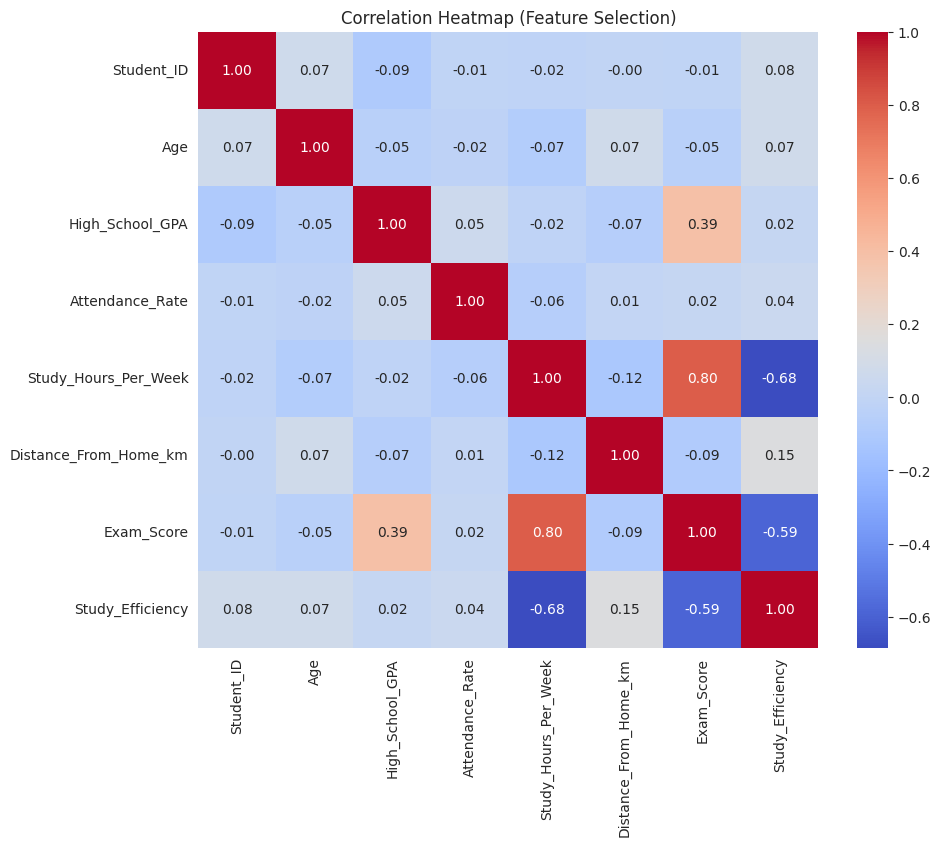

In [84]:
plt.figure(figsize=(10, 8))
numeric_cols_viz = df_viz.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols_viz.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (Feature Selection)')
plt.show()